#📌 End-to-End Data Science Project

###Predicting Instagram Likes Using Regression



In [1]:
path = '/content/Instagram data actual.csv'

| Column Name    | Category     | Description                                                             |
| -------------- | ------------ | ----------------------------------------------------------------------- |
| Impressions    | Reach        | Total number of times the post was displayed on users’ screens          |
| From Home      | Reach Source | Impressions generated from users’ Home feed                             |
| From Hashtags  | Reach Source | Impressions generated through hashtags                                  |
| From Explore   | Reach Source | Impressions generated from the Explore page                             |
| From Other     | Reach Source | Impressions from other sources (shares, profile visits, external links) |
| Saves          | Engagement   | Number of times users saved the post                                    |
| Comments       | Engagement   | Number of comments received on the post                                 |
| Shares         | Engagement   | Number of times the post was shared                                     |
| Likes          | Engagement   | Number of likes received on the post                                    |
| Profile Visits | Conversion   | Number of profile visits generated by the post                          |
| Follows        | Conversion   | Number of new followers gained from the post                            |
| Caption        | Content      | Text content of the post caption                                        |
| Hashtags       | Content      | Hashtags used in the post                                               |


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('ggplot')
import seaborn as sns


from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split as tts
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import r2_score,mean_absolute_error,mean_absolute_percentage_error

import pickle

import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import PowerTransformer


df = pd.read_csv(path,encoding='latin')
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...
3,4528,2700,621,932,73,172,10,7,213,23,8,Heres how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...


In [3]:
df.shape

(126, 13)

In [4]:
df.columns

Index(['Impressions', 'From Home', 'From Hashtags', 'From Explore',
       'From Other', 'Saves', 'Comments', 'Shares', 'Likes', 'Profile Visits',
       'Follows', 'Caption', 'Hashtags'],
      dtype='object')

In [5]:
df.size

1638

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Impressions     126 non-null    int64 
 1   From Home       126 non-null    int64 
 2   From Hashtags   126 non-null    int64 
 3   From Explore    126 non-null    int64 
 4   From Other      126 non-null    int64 
 5   Saves           126 non-null    int64 
 6   Comments        126 non-null    int64 
 7   Shares          126 non-null    int64 
 8   Likes           126 non-null    int64 
 9   Profile Visits  126 non-null    int64 
 10  Follows         126 non-null    int64 
 11  Caption         126 non-null    object
 12  Hashtags        126 non-null    object
dtypes: int64(11), object(2)
memory usage: 12.9+ KB


In [7]:
df.duplicated().sum()

np.int64(24)

In [8]:
df[df.duplicated()]

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags
82,5055,2017,2351,298,108,101,7,11,159,17,6,"In Data Science, Time Series Analysis is a met...",#timeseries #time #statistics #datascience #bi...
83,4002,3401,278,128,73,111,17,18,205,16,2,Here are some of the highest paying skills in ...,#career #job #jobs #jobsearch #education #busi...
84,3169,1979,707,341,32,106,8,1,121,21,2,"In Data Science, Time Series Analysis is a met...",#timeseries #time #statistics #datascience #bi...
85,6168,2177,3450,153,296,82,6,6,151,77,30,"Stress, anxiety, and depression are threatenin...",#data #datascience #dataanalysis #dataanalytic...
86,2407,1338,655,276,39,40,8,20,72,10,0,Data Science Use Cases: Heres how Zomato is u...,#data #datascience #dataanalysis #dataanalytic...
87,3630,1747,1693,72,86,137,4,10,137,14,4,Here are some of the best data analysis projec...,#data #datascience #dataanalysis #dataanalytic...
88,2826,2108,583,76,34,67,3,3,114,30,4,Visualizing data is one of the most valuable s...,#dataanalytics #datascience #data #machinelear...
89,7407,2782,1938,2237,226,288,5,15,263,39,18,Here are some of the most important machine le...,#data #datascience #dataanalysis #dataanalytic...
90,10386,4137,3551,2355,205,668,8,41,328,42,38,Here are some of the best websites that you ca...,#data #datascience #dataanalysis #dataanalytic...
91,2998,1945,794,84,139,42,4,1,126,31,10,Time series analysis means analyzing and findi...,#timeseries #time #statistics #datascience #bi...


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df.shape

(102, 13)

#Caption Feature Engineering


In [11]:
df['caption_len'] = df['Caption'].apply(lambda x:len(x.split(' ')))

In [12]:
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Caption,Hashtags,caption_len
0,3920,2586,1028,619,56,98,9,5,162,35,2,Here are some of the most important data visua...,#finance #money #business #investing #investme...,16
1,5394,2727,1838,1174,78,194,7,14,224,48,10,Here are some of the best data science project...,#healthcare #health #covid #data #datascience ...,34
2,4021,2085,1188,0,533,41,11,1,131,62,12,Learn how to train a machine learning model an...,#data #datascience #dataanalysis #dataanalytic...,20
3,4528,2700,621,932,73,172,10,7,213,23,8,Heres how you can write a Python program to d...,#python #pythonprogramming #pythonprojects #py...,41
4,2518,1704,255,279,37,96,5,4,123,8,0,Plotting annotations while visualizing your da...,#datavisualization #datascience #data #dataana...,28


In [14]:
df.drop(['Caption'],axis=1,inplace=True)

KeyError: "['Caption'] not found in axis"

In [15]:
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Hashtags,caption_len
0,3920,2586,1028,619,56,98,9,5,162,35,2,#finance #money #business #investing #investme...,16
1,5394,2727,1838,1174,78,194,7,14,224,48,10,#healthcare #health #covid #data #datascience ...,34
2,4021,2085,1188,0,533,41,11,1,131,62,12,#data #datascience #dataanalysis #dataanalytic...,20
3,4528,2700,621,932,73,172,10,7,213,23,8,#python #pythonprogramming #pythonprojects #py...,41
4,2518,1704,255,279,37,96,5,4,123,8,0,#datavisualization #datascience #data #dataana...,28


In [16]:
df['Hashtags'].loc[0]

'#finance\xa0#money\xa0#business\xa0#investing\xa0#investment\xa0#trading\xa0#stockmarket\xa0#data\xa0#datascience\xa0#dataanalysis\xa0#dataanalytics\xa0#datascientist\xa0#machinelearning\xa0#python\xa0#pythonprogramming\xa0#pythonprojects\xa0#pythoncode\xa0#artificialintelligence\xa0#ai\xa0#dataanalyst\xa0#amankharwal\xa0#thecleverprogrammer'

#Hashtag Feature Engineering

In [17]:
df['hashtag_len'] = df['Hashtags'].apply(lambda x:len(x.split('\xa0')))

In [18]:
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,Hashtags,caption_len,hashtag_len
0,3920,2586,1028,619,56,98,9,5,162,35,2,#finance #money #business #investing #investme...,16,22
1,5394,2727,1838,1174,78,194,7,14,224,48,10,#healthcare #health #covid #data #datascience ...,34,18
2,4021,2085,1188,0,533,41,11,1,131,62,12,#data #datascience #dataanalysis #dataanalytic...,20,18
3,4528,2700,621,932,73,172,10,7,213,23,8,#python #pythonprogramming #pythonprojects #py...,41,11
4,2518,1704,255,279,37,96,5,4,123,8,0,#datavisualization #datascience #data #dataana...,28,29


#Hashtag Analysis

- Best performing hashtags as per Likes , Impressions etc

In [19]:
l = df['Hashtags'].values.tolist()

result = []
for i in l:
  result.extend(i.split('\xa0'))

data = pd.DataFrame()
data['hashtags'] = result

data.head()

,hashtags
0,#finance
1,#money
2,#business
3,#investing
4,#investment


In [20]:
data['hashtags'].value_counts()

,count
hashtags,
#amankharwal,100
#thecleverprogrammer,100
#python,93
#pythonprogramming,84
#pythonprojects,82
...,...
#whatsapp,1
#pythonprogram,1
@codergallery,1


In [21]:
df.drop(['Hashtags'],axis=1,inplace=True)

In [22]:
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Likes,Profile Visits,Follows,caption_len,hashtag_len
0,3920,2586,1028,619,56,98,9,5,162,35,2,16,22
1,5394,2727,1838,1174,78,194,7,14,224,48,10,34,18
2,4021,2085,1188,0,533,41,11,1,131,62,12,20,18
3,4528,2700,621,932,73,172,10,7,213,23,8,41,11
4,2518,1704,255,279,37,96,5,4,123,8,0,28,29


In [23]:
df.columns

Index(['Impressions', 'From Home', 'From Hashtags', 'From Explore',
       'From Other', 'Saves', 'Comments', 'Shares', 'Likes', 'Profile Visits',
       'Follows', 'caption_len', 'hashtag_len'],
      dtype='object')

In [24]:
df = df[['Impressions', 'From Home', 'From Hashtags', 'From Explore',
       'From Other', 'Saves', 'Comments', 'Shares', 'Profile Visits',
       'Follows', 'caption_len', 'hashtag_len','Likes']]

df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Profile Visits,Follows,caption_len,hashtag_len,Likes
0,3920,2586,1028,619,56,98,9,5,35,2,16,22,162
1,5394,2727,1838,1174,78,194,7,14,48,10,34,18,224
2,4021,2085,1188,0,533,41,11,1,62,12,20,18,131
3,4528,2700,621,932,73,172,10,7,23,8,41,11,213
4,2518,1704,255,279,37,96,5,4,8,0,28,29,123


In [25]:
(df<0).sum()

,0
Impressions,0
From Home,0
From Hashtags,0
From Explore,0
From Other,0
Saves,0
Comments,0
Shares,0
Profile Visits,0
Follows,0


In [26]:
(df['Likes']>df['Impressions']).sum()

np.int64(0)

In [27]:
df.shape

(102, 13)

#📉 PART 2: Outlier Detection & Treatment

In [28]:
df.columns

Index(['Impressions', 'From Home', 'From Hashtags', 'From Explore',
       'From Other', 'Saves', 'Comments', 'Shares', 'Profile Visits',
       'Follows', 'caption_len', 'hashtag_len', 'Likes'],
      dtype='object')

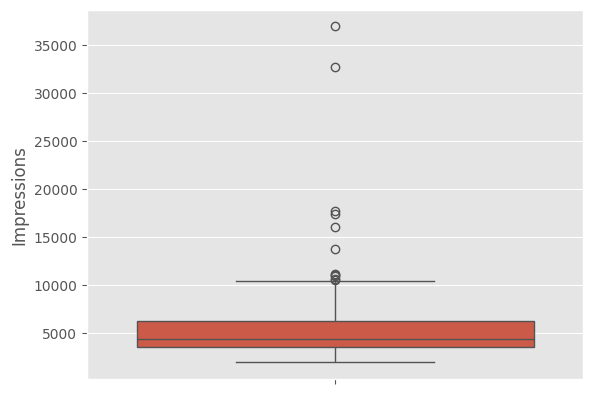

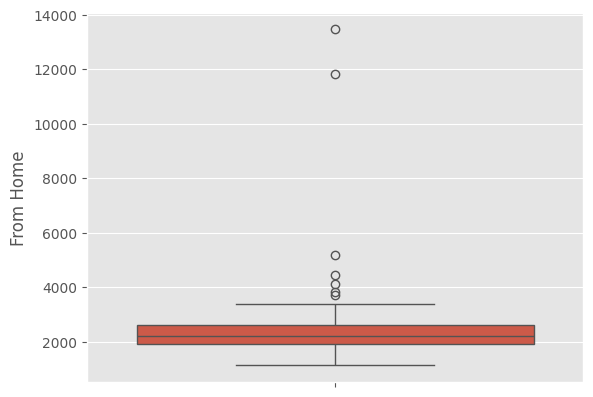

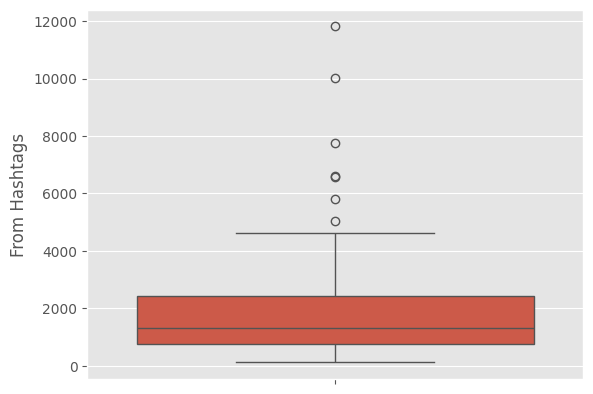

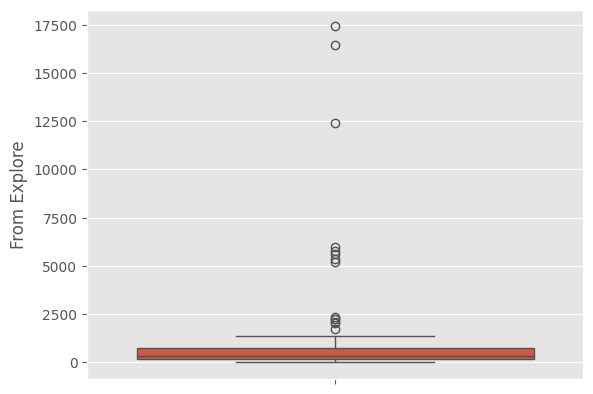

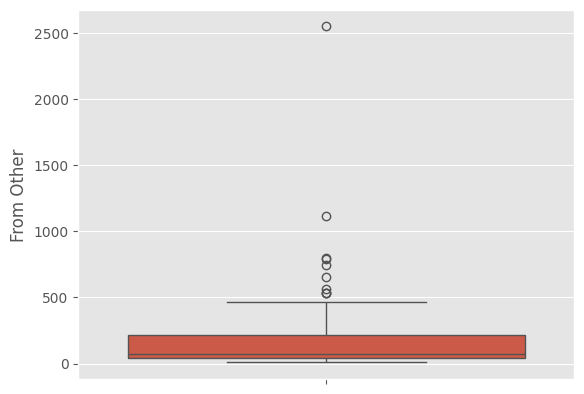

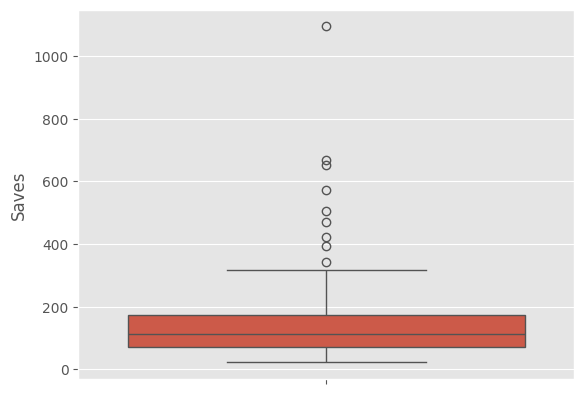

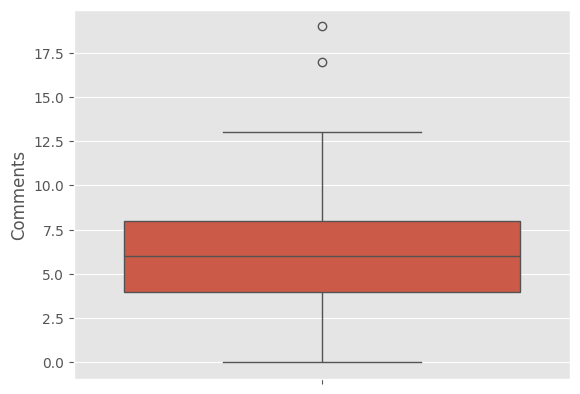

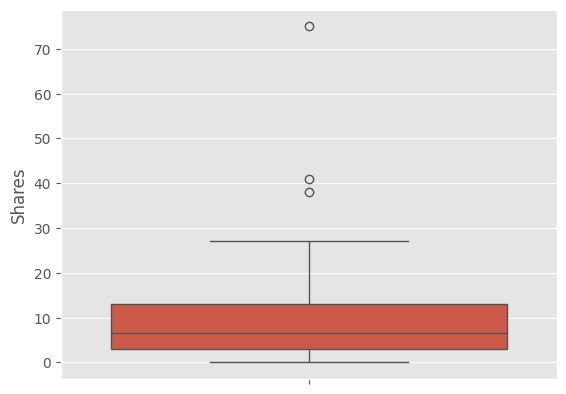

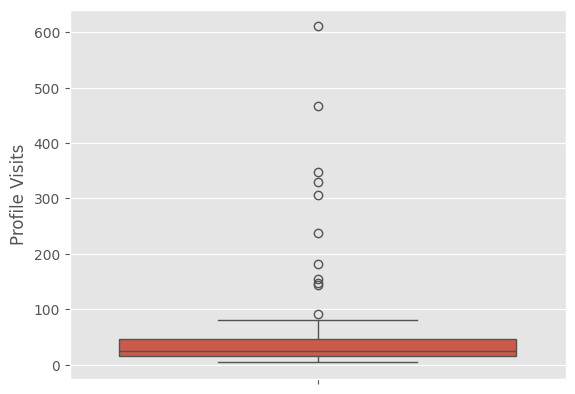

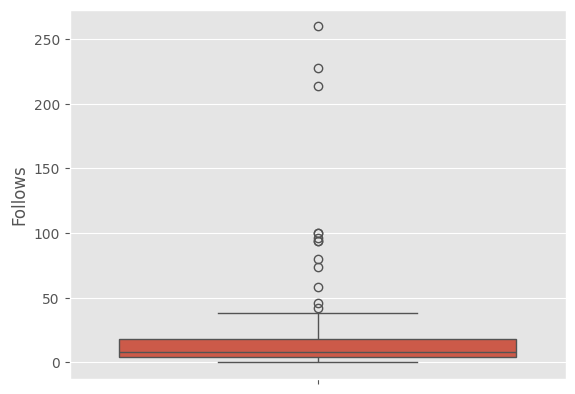

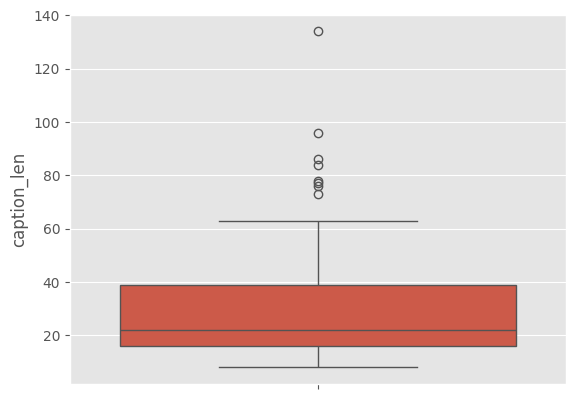

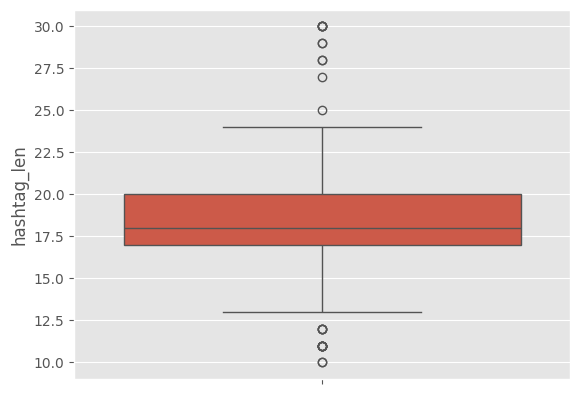

In [29]:
num_cols = ['Impressions', 'From Home', 'From Hashtags', 'From Explore',
       'From Other', 'Saves', 'Comments', 'Shares', 'Profile Visits',
       'Follows', 'caption_len', 'hashtag_len']

for col in num_cols:
  sns.boxplot(df[col])
  plt.show()

- we cant drop the outliers because data is only 102 rows and if we drop outliers it will result in even lesser data that will have an impact on the model performance  

#🧪 PART 3: Hypothesis Testing & Statistical Analysis

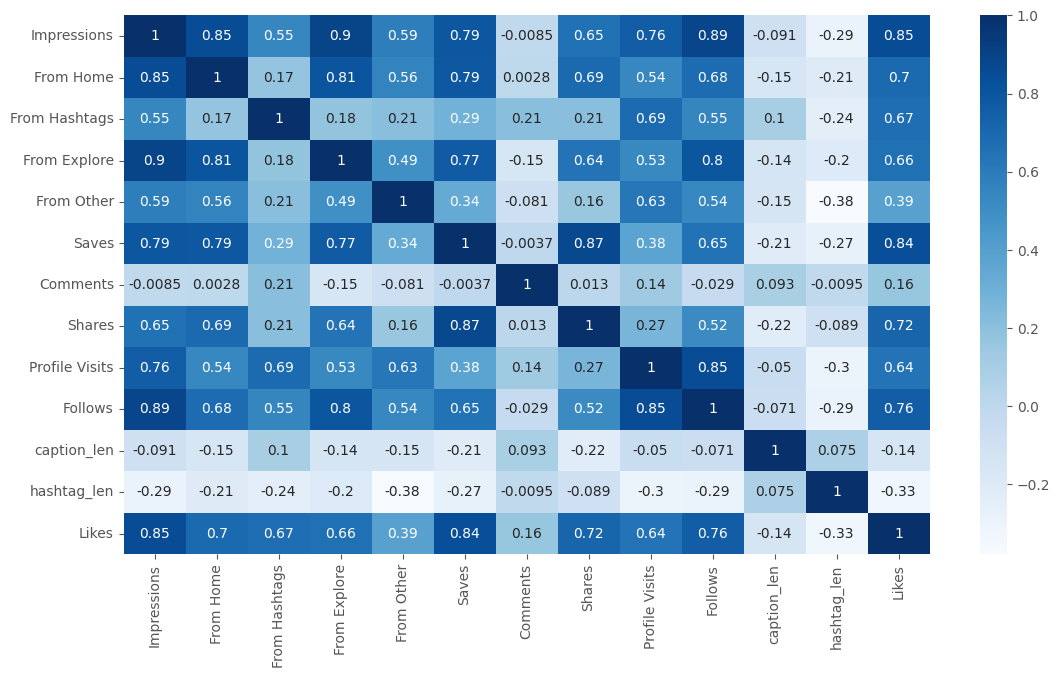

In [30]:
plt.figure(figsize=(13,7))
sns.heatmap(df.corr(),annot=True,cmap='Blues')
plt.show()

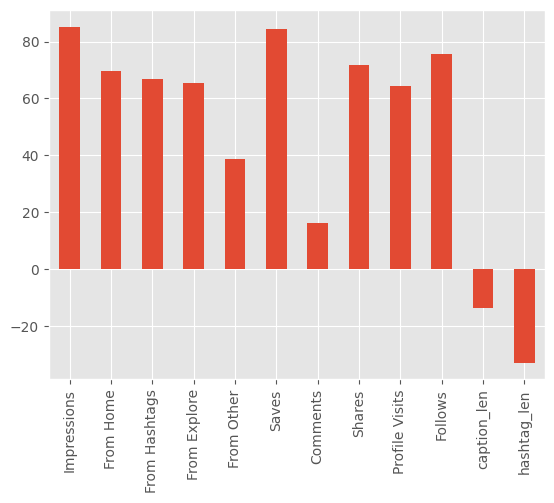

In [31]:
(df.corr()['Likes'].drop(['Likes'])*100).plot.bar()
plt.show()

In [32]:
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Profile Visits,Follows,caption_len,hashtag_len,Likes
0,3920,2586,1028,619,56,98,9,5,35,2,16,22,162
1,5394,2727,1838,1174,78,194,7,14,48,10,34,18,224
2,4021,2085,1188,0,533,41,11,1,62,12,20,18,131
3,4528,2700,621,932,73,172,10,7,23,8,41,11,213
4,2518,1704,255,279,37,96,5,4,8,0,28,29,123


#Converting from explore to a binary column just for the sake of showcasing how we can convert numerical data into categorical to run stats test or groupby to see differences

In [33]:
df['From Explore'].describe()

,From Explore
count,102.000000
mean,1178.568627
std,2797.212621
min,0.000000
25%,178.750000
50%,337.000000
75%,728.500000
max,17414.000000


In [34]:
df['From Explore'].median()

337.0

In [35]:
df['explore_binary'] = df['From Explore'].apply(lambda x : 'low' if x<337 else 'high')
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Profile Visits,Follows,caption_len,hashtag_len,Likes,explore_binary
0,3920,2586,1028,619,56,98,9,5,35,2,16,22,162,high
1,5394,2727,1838,1174,78,194,7,14,48,10,34,18,224,high
2,4021,2085,1188,0,533,41,11,1,62,12,20,18,131,low
3,4528,2700,621,932,73,172,10,7,23,8,41,11,213,high
4,2518,1704,255,279,37,96,5,4,8,0,28,29,123,low


In [36]:
df.groupby(['explore_binary'])['Likes'].mean()

,Likes
explore_binary,
high,213.176471
low,140.470588


In [37]:
df.drop(['explore_binary'],axis=1,inplace=True)

#📊 PART 4: Exploratory Data Analysis (EDA)

In [38]:
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Profile Visits,Follows,caption_len,hashtag_len,Likes
0,3920,2586,1028,619,56,98,9,5,35,2,16,22,162
1,5394,2727,1838,1174,78,194,7,14,48,10,34,18,224
2,4021,2085,1188,0,533,41,11,1,62,12,20,18,131
3,4528,2700,621,932,73,172,10,7,23,8,41,11,213
4,2518,1704,255,279,37,96,5,4,8,0,28,29,123


In [ ]:
df.shape

(102, 13)

#Univariate Analysis

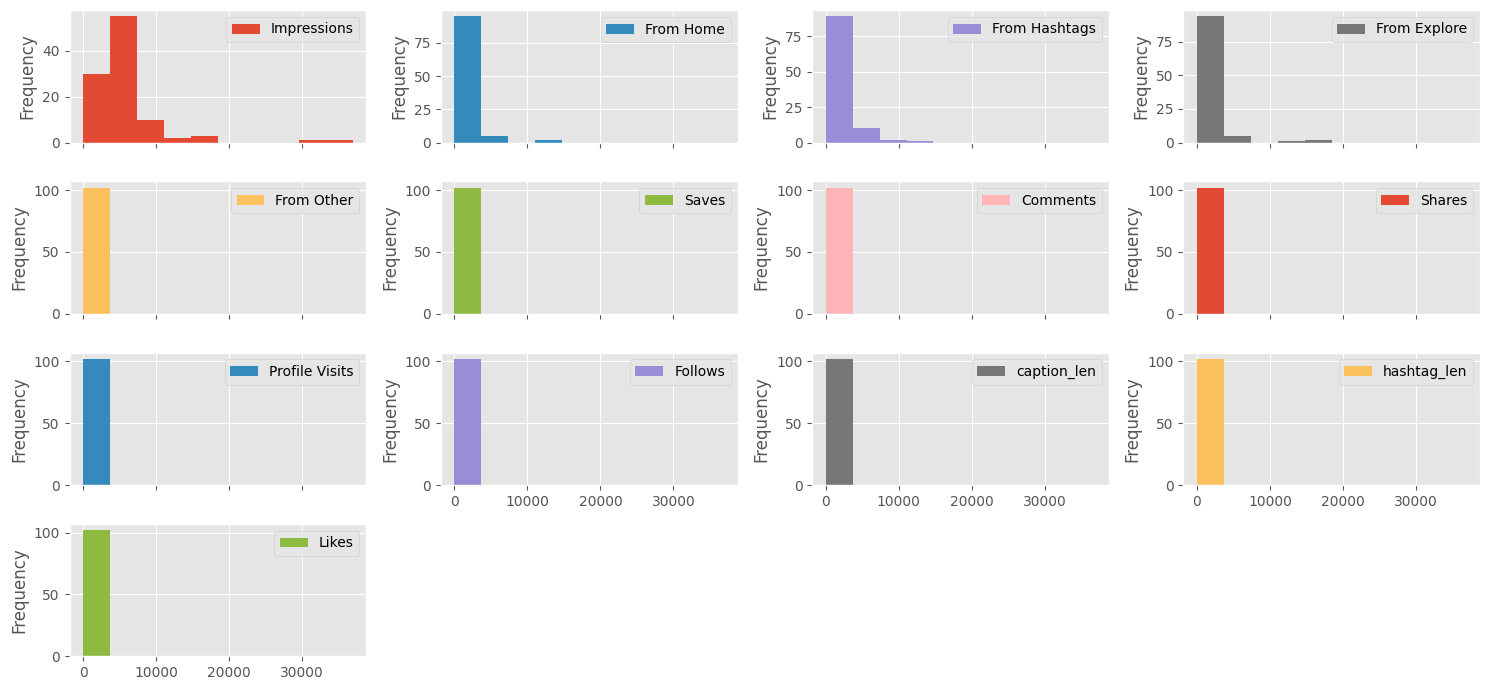

In [39]:
df.plot(kind='hist',subplots=True,figsize=(15,7),layout=(4,4))
plt.tight_layout()
plt.show()

In [ ]:
df.columns

Index(['Impressions', 'From Home', 'From Hashtags', 'From Explore',
       'From Other', 'Saves', 'Comments', 'Shares', 'Profile Visits',
       'Follows', 'caption_len', 'hashtag_len', 'Likes'],
      dtype='object')

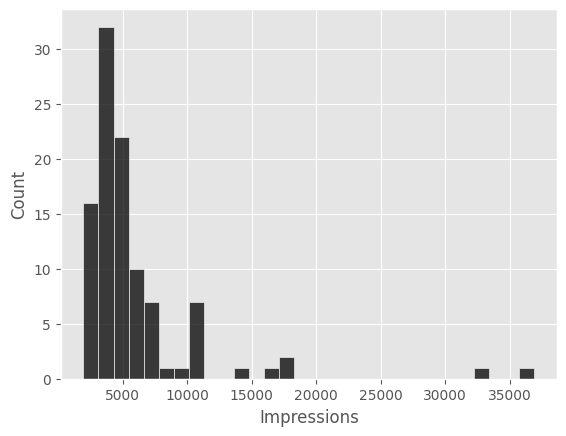

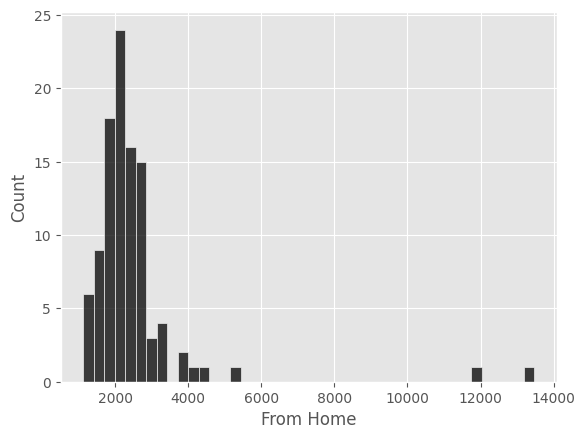

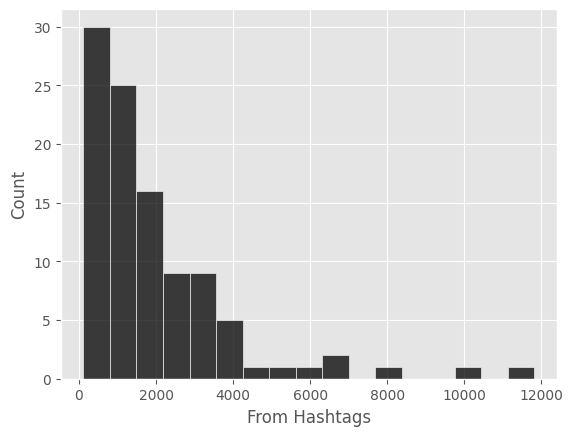

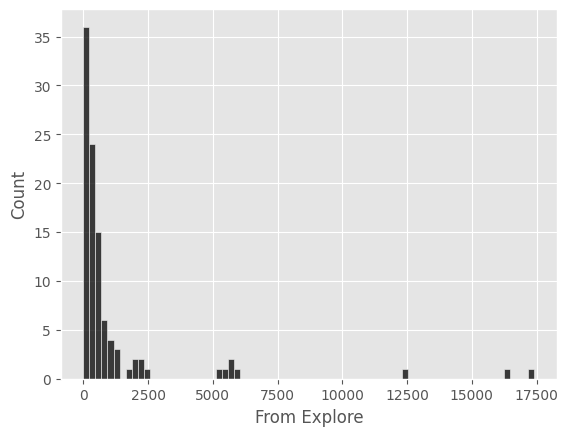

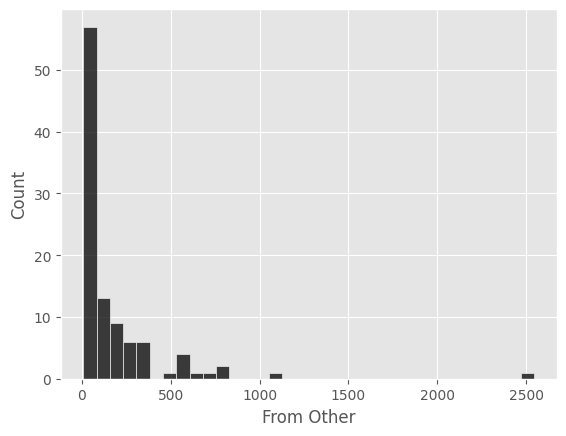

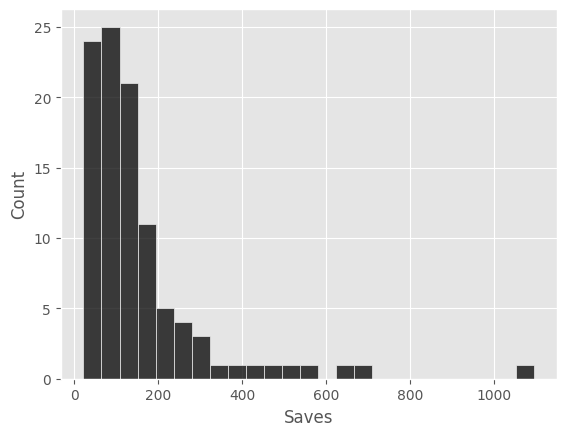

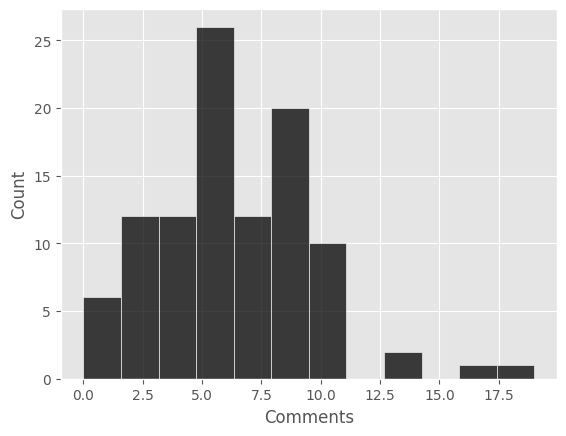

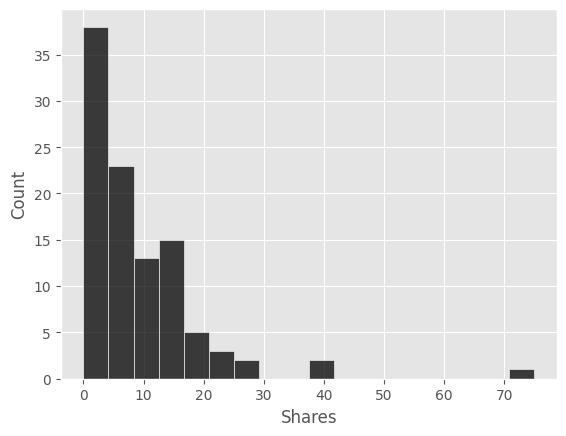

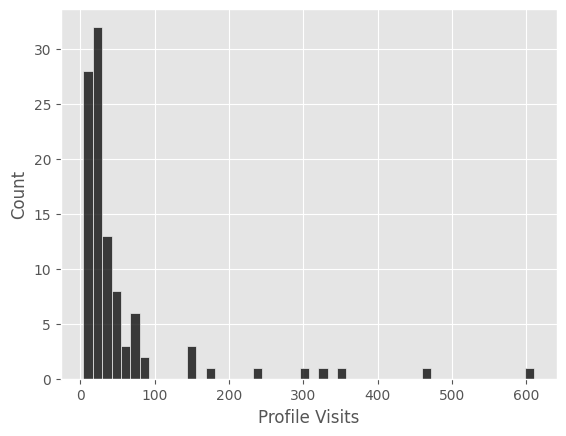

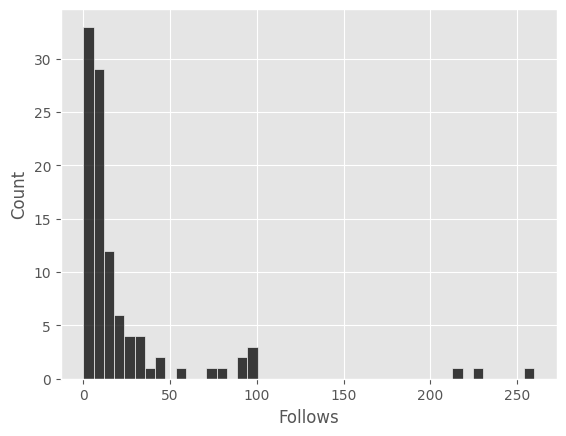

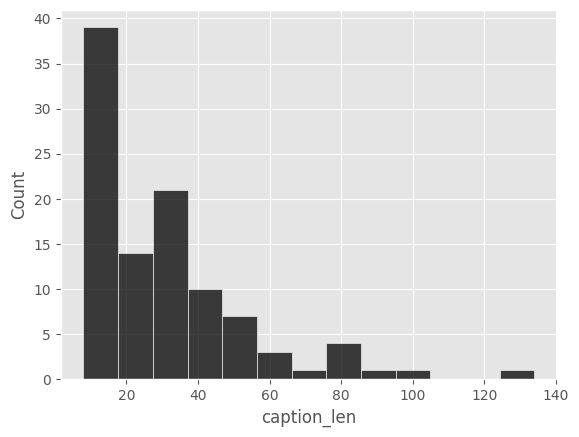

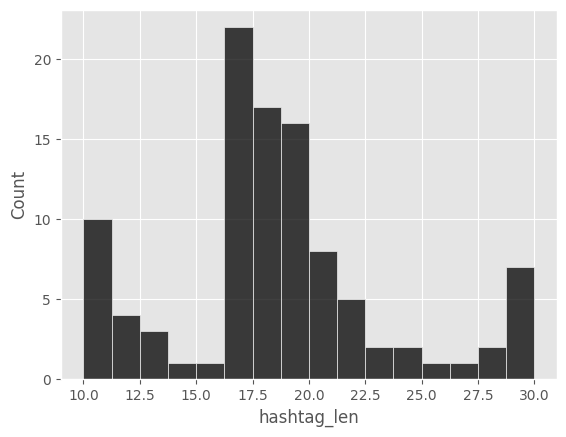

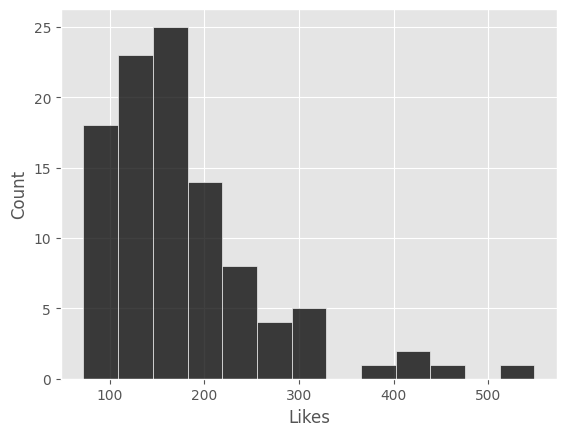

In [40]:
for col in df.columns:
  sns.histplot(df[col],color='k')
  plt.show()

- data is skewed(right skewed majorly)

#Bivariate Analysis

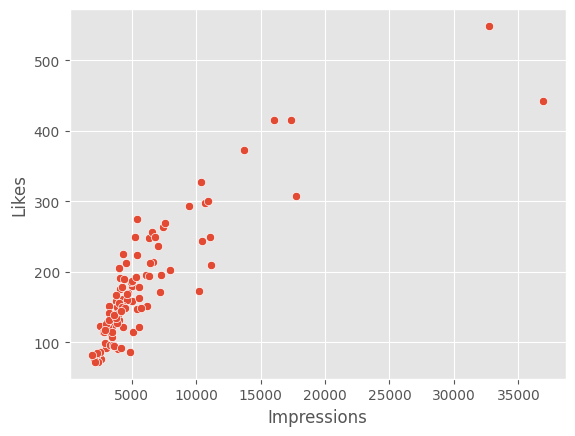

In [41]:
sns.scatterplot(data=df,x ='Impressions' ,y='Likes')
plt.show()

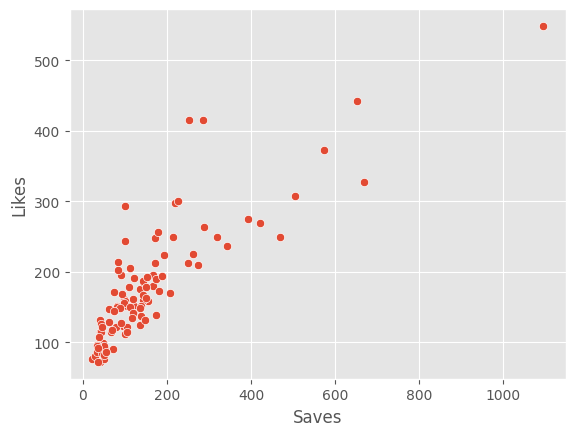

In [42]:
sns.scatterplot(data=df,x = 'Saves',y='Likes')
plt.show()

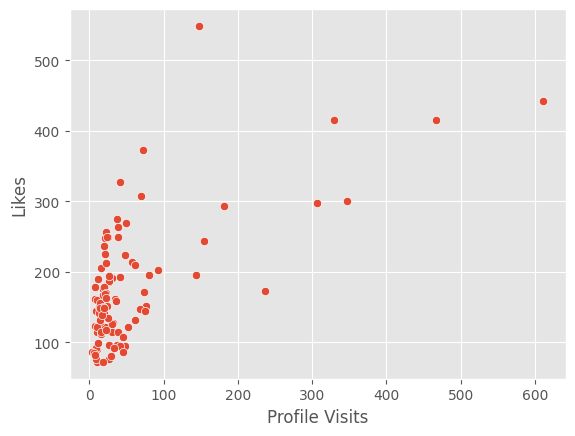

In [43]:
sns.scatterplot(data=df,x = 'Profile Visits',y='Likes')
plt.show()

In [44]:
df[['Impressions','Saves','Profile Visits','Likes']].corr()

,Impressions,Saves,Profile Visits,Likes
Impressions,1.000000,0.791448,0.762679,0.852952
Saves,0.791448,1.000000,0.377424,0.843395
Profile Visits,0.762679,0.377424,1.000000,0.642658
Likes,0.852952,0.843395,0.642658,1.000000


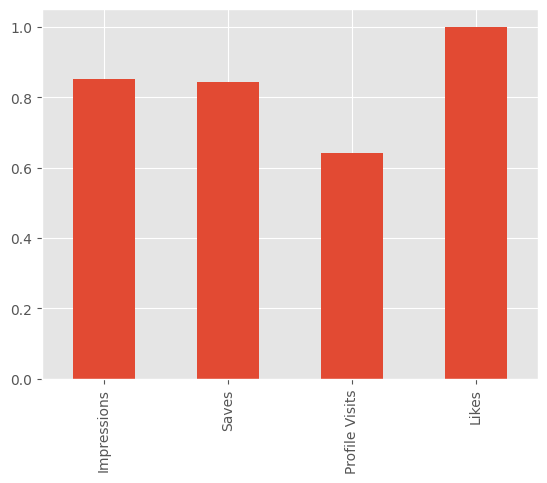

In [45]:
df[['Impressions','Saves','Profile Visits','Likes']].corr()['Likes'].plot.bar()
plt.show()

#Multivariate Analysis

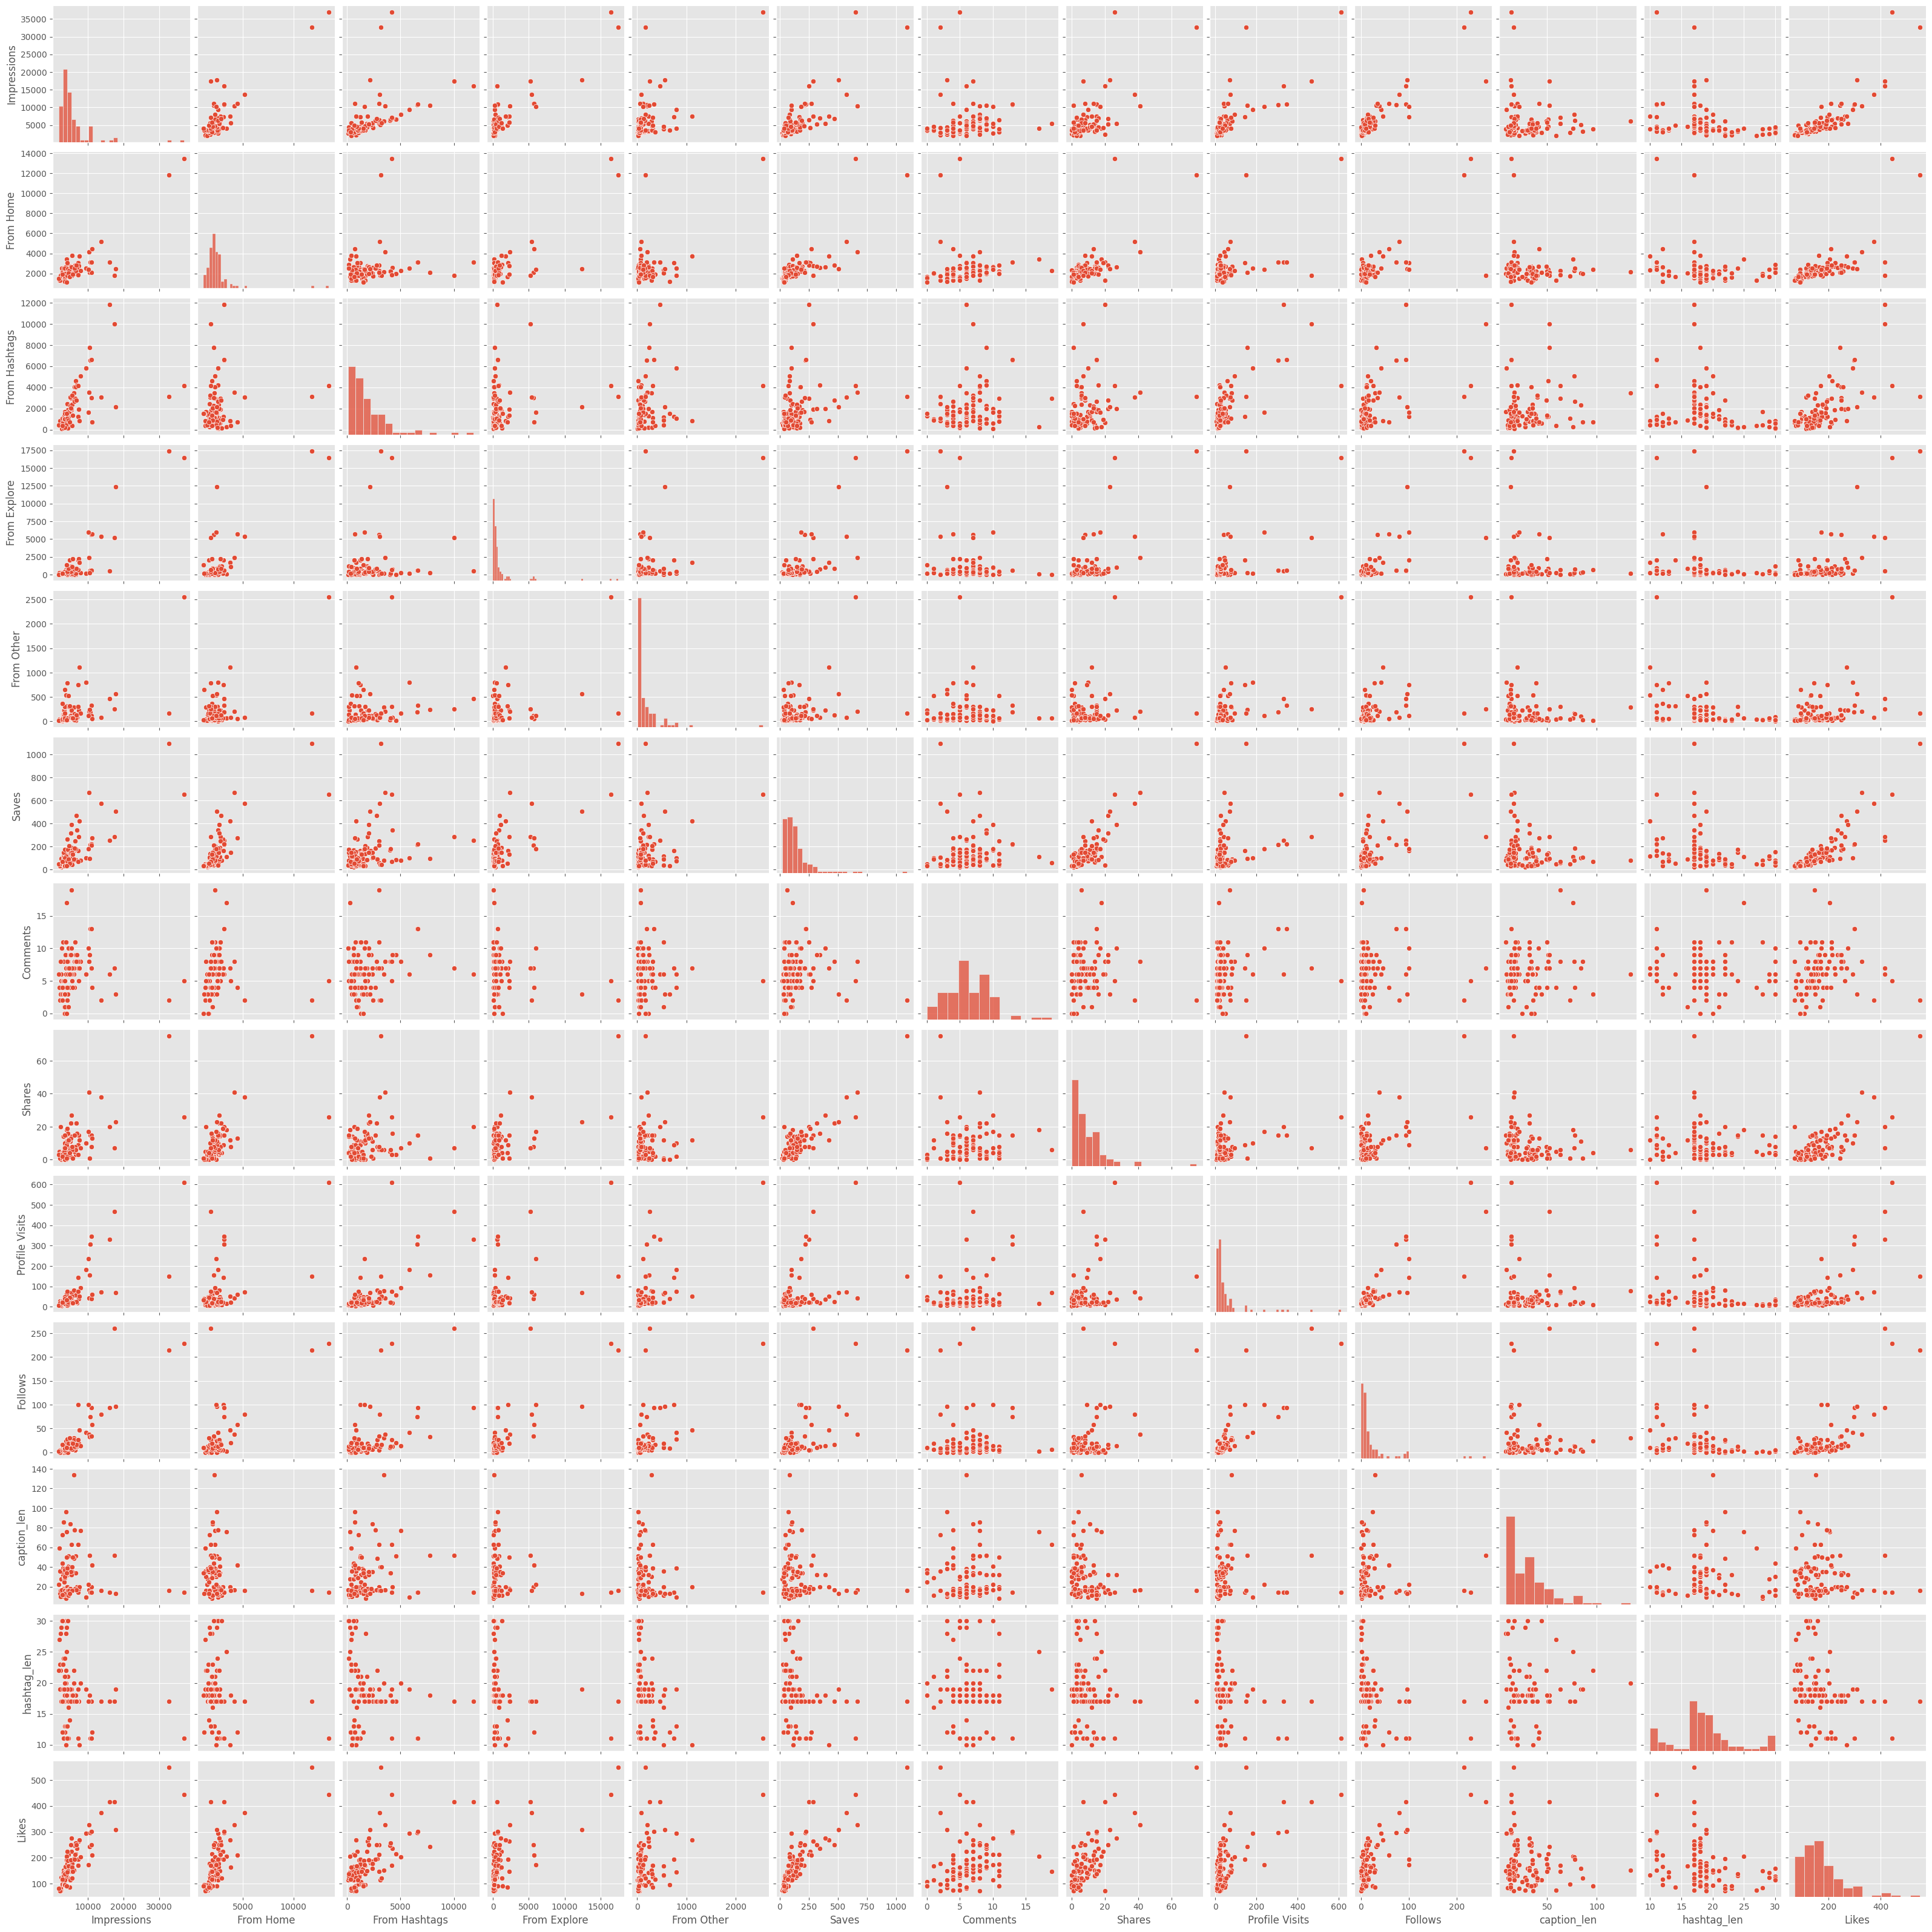

In [46]:
sns.pairplot(df)
plt.show()

#Distribution Analysis

In [47]:
df.skew()

,0
Impressions,3.977725
From Home,5.404506
From Hashtags,2.504723
From Explore,4.440369
From Other,5.057236
Saves,3.172985
Comments,0.761900
Shares,3.344877
Profile Visits,3.885906
Follows,3.753263


In [48]:
df.kurtosis()

,0
Impressions,19.417842
From Home,33.484056
From Hashtags,8.106063
From Explore,21.208058
From Other,34.227684
Saves,13.440310
Comments,1.888437
Shares,17.459759
Profile Visits,16.916099
Follows,15.517510


In [49]:
cols = df.columns[:-1].tolist()
cols

['Impressions',
 'From Home',
 'From Hashtags',
 'From Explore',
 'From Other',
 'Saves',
 'Comments',
 'Shares',
 'Profile Visits',
 'Follows',
 'caption_len',
 'hashtag_len']

In [50]:
pt = PowerTransformer(method='yeo-johnson')
#never change or tx the target variable ever

df[cols] = pt.fit_transform(df[cols])

In [51]:
df.skew()

,0
Impressions,0.019880
From Home,-0.147703
From Hashtags,-0.003884
From Explore,0.012839
From Other,0.044000
Saves,0.012220
Comments,0.043375
Shares,-0.005491
Profile Visits,0.030665
Follows,-0.001356


In [52]:
df.kurtosis()

,0
Impressions,0.069190
From Home,1.539721
From Hashtags,-0.059207
From Explore,2.123515
From Other,-0.513884
Saves,-0.254342
Comments,0.798119
Shares,-0.106539
Profile Visits,0.035678
Follows,0.116561


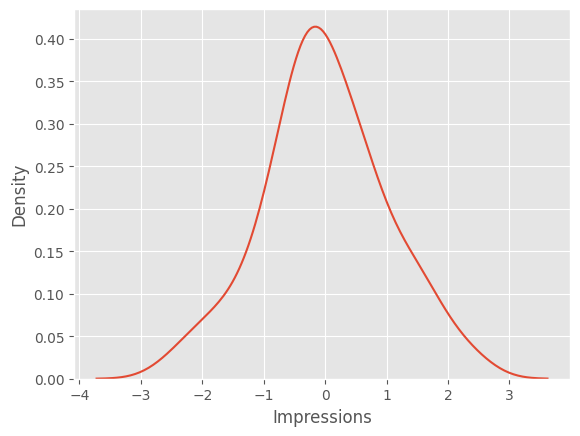

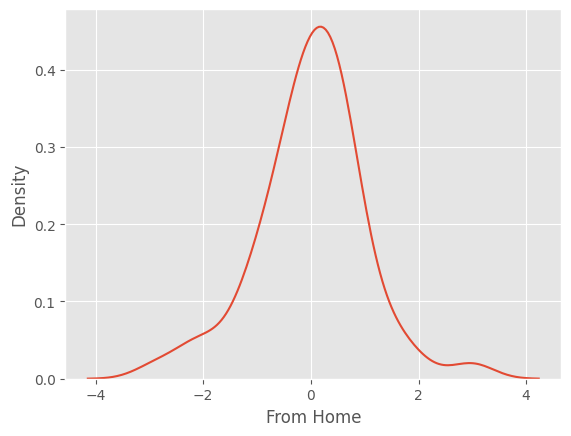

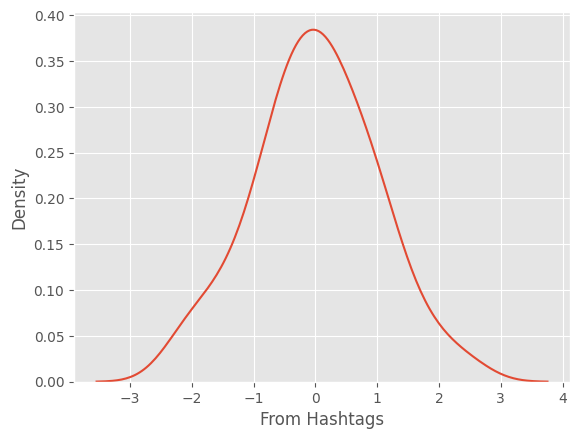

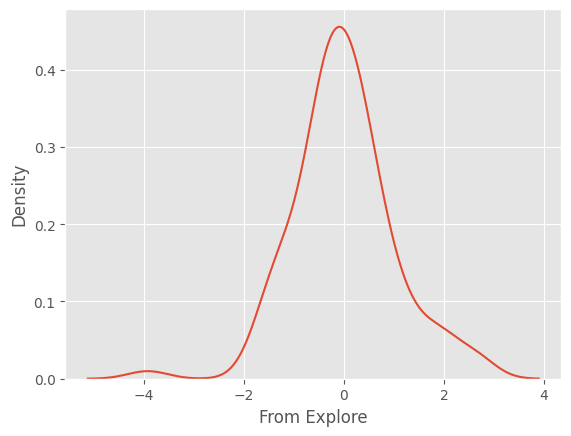

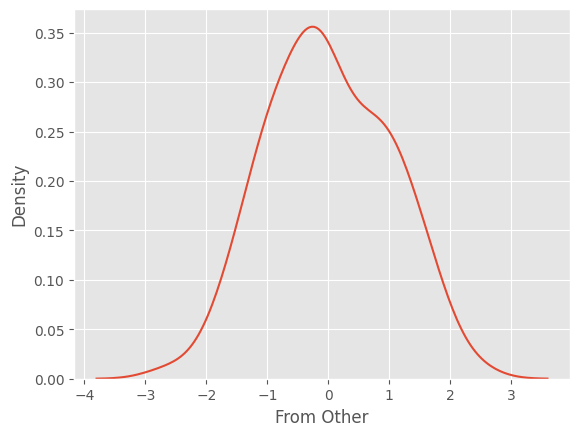

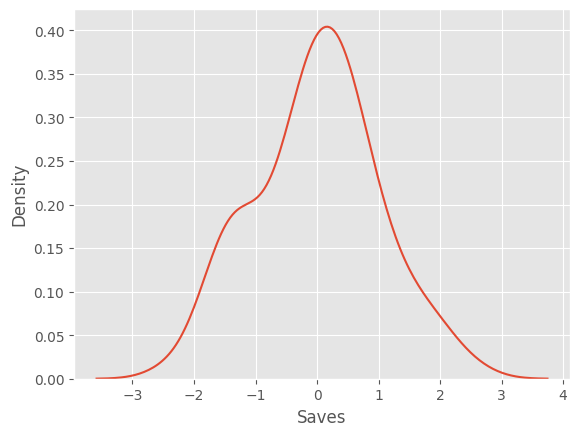

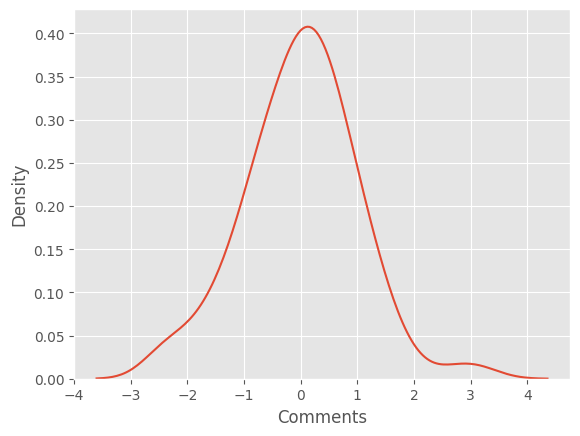

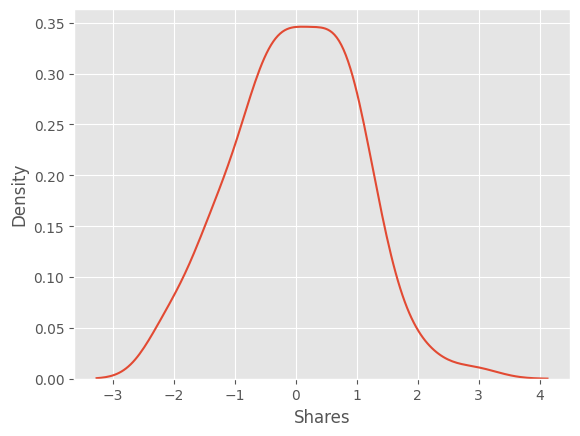

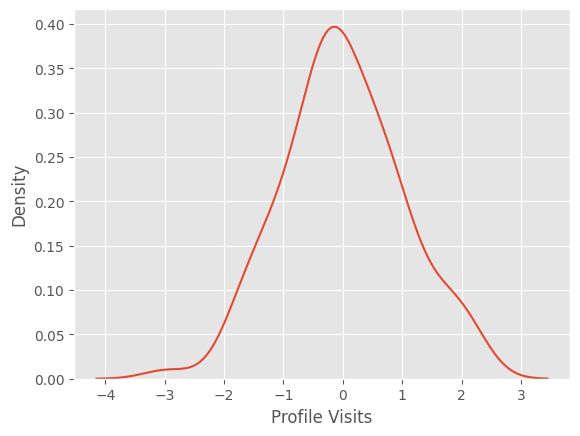

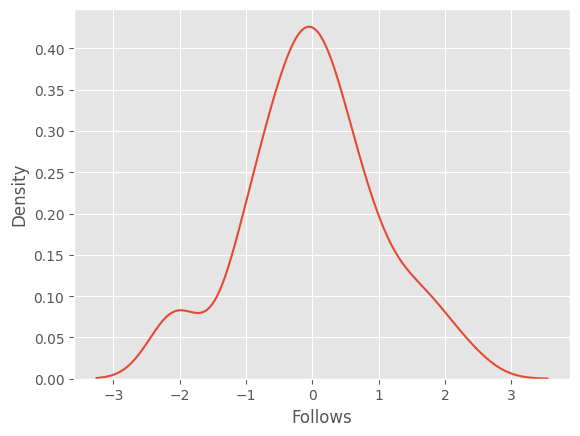

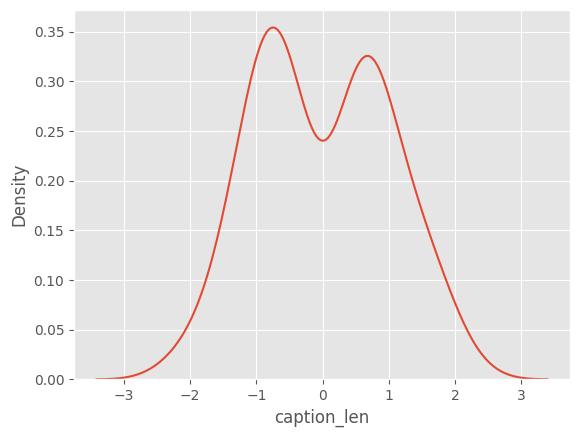

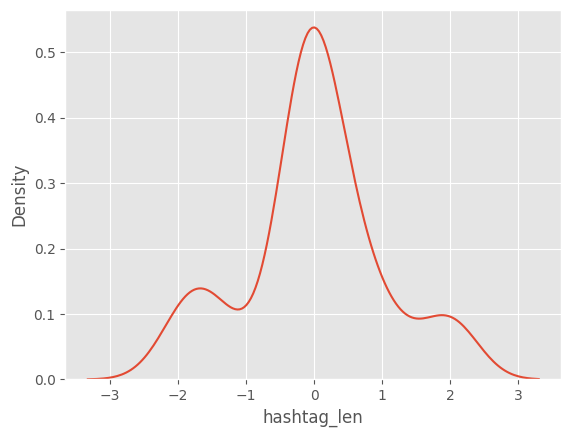

In [53]:
for col in cols:
  sns.kdeplot(df[col])
  plt.show()

In [54]:
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Profile Visits,Follows,caption_len,hashtag_len,Likes
0,-0.319495,0.529220,-0.294557,0.342933,-0.408193,-0.133753,0.833489,-0.229660,0.357805,-1.002060,-0.719873,0.773939,162
1,0.374807,0.678281,0.327131,0.786424,-0.075061,0.737183,0.276850,0.829918,0.679904,0.118860,0.578814,-0.027495,224
2,-0.258289,-0.151690,-0.142926,-3.919125,1.493050,-1.389649,1.350448,-1.390200,0.915037,0.253529,-0.300586,-0.027495,131
3,0.013421,0.650868,-0.807132,0.626019,-0.140060,0.590599,1.096284,0.093657,-0.129909,-0.045662,0.851904,-1.809826,213
4,-1.579242,-0.917335,-1.654799,-0.203421,-0.853541,-0.161565,-0.333958,-0.430278,-1.687740,-2.059854,0.275632,1.952001,123


#PART 5: Feature Engineering

In [55]:
#Save Rate

df['save_rate'] = df['Saves']/df['Impressions']

df['share_rate'] = df['Shares']/df['Impressions']

df['Profile_Visit_Rate'] = df['Profile Visits']/df['Impressions']



In [56]:
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Profile Visits,Follows,caption_len,hashtag_len,Likes,save_rate,share_rate,Profile_Visit_Rate
0,-0.319495,0.529220,-0.294557,0.342933,-0.408193,-0.133753,0.833489,-0.229660,0.357805,-1.002060,-0.719873,0.773939,162,0.418639,0.718822,-1.119907
1,0.374807,0.678281,0.327131,0.786424,-0.075061,0.737183,0.276850,0.829918,0.679904,0.118860,0.578814,-0.027495,224,1.966833,2.214254,1.814011
2,-0.258289,-0.151690,-0.142926,-3.919125,1.493050,-1.389649,1.350448,-1.390200,0.915037,0.253529,-0.300586,-0.027495,131,5.380208,5.382341,-3.542685
3,0.013421,0.650868,-0.807132,0.626019,-0.140060,0.590599,1.096284,0.093657,-0.129909,-0.045662,0.851904,-1.809826,213,44.005221,6.978364,-9.679453
4,-1.579242,-0.917335,-1.654799,-0.203421,-0.853541,-0.161565,-0.333958,-0.430278,-1.687740,-2.059854,0.275632,1.952001,123,0.102305,0.272459,1.068703


In [57]:
df.columns

Index(['Impressions', 'From Home', 'From Hashtags', 'From Explore',
       'From Other', 'Saves', 'Comments', 'Shares', 'Profile Visits',
       'Follows', 'caption_len', 'hashtag_len', 'Likes', 'save_rate',
       'share_rate', 'Profile_Visit_Rate'],
      dtype='object')

In [58]:
df = df[['Impressions', 'From Home', 'From Hashtags', 'From Explore',
       'From Other', 'Saves', 'Comments', 'Shares', 'Profile Visits',
       'Follows', 'caption_len', 'hashtag_len', 'save_rate',
       'share_rate', 'Profile_Visit_Rate', 'Likes']]
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Profile Visits,Follows,caption_len,hashtag_len,save_rate,share_rate,Profile_Visit_Rate,Likes
0,-0.319495,0.529220,-0.294557,0.342933,-0.408193,-0.133753,0.833489,-0.229660,0.357805,-1.002060,-0.719873,0.773939,0.418639,0.718822,-1.119907,162
1,0.374807,0.678281,0.327131,0.786424,-0.075061,0.737183,0.276850,0.829918,0.679904,0.118860,0.578814,-0.027495,1.966833,2.214254,1.814011,224
2,-0.258289,-0.151690,-0.142926,-3.919125,1.493050,-1.389649,1.350448,-1.390200,0.915037,0.253529,-0.300586,-0.027495,5.380208,5.382341,-3.542685,131
3,0.013421,0.650868,-0.807132,0.626019,-0.140060,0.590599,1.096284,0.093657,-0.129909,-0.045662,0.851904,-1.809826,44.005221,6.978364,-9.679453,213
4,-1.579242,-0.917335,-1.654799,-0.203421,-0.853541,-0.161565,-0.333958,-0.430278,-1.687740,-2.059854,0.275632,1.952001,0.102305,0.272459,1.068703,123


#PART 6: Feature Selection

In [59]:
df.corr()['Likes']*100

,Likes
Impressions,83.597857
From Home,70.060484
From Hashtags,61.970641
From Explore,57.360997
From Other,41.297870
Saves,81.071576
Comments,17.372595
Shares,62.857215
Profile Visits,59.263532
Follows,67.189744


#PART 7: Modeling

In [60]:
df.head()

,Impressions,From Home,From Hashtags,From Explore,From Other,Saves,Comments,Shares,Profile Visits,Follows,caption_len,hashtag_len,save_rate,share_rate,Profile_Visit_Rate,Likes
0,-0.319495,0.529220,-0.294557,0.342933,-0.408193,-0.133753,0.833489,-0.229660,0.357805,-1.002060,-0.719873,0.773939,0.418639,0.718822,-1.119907,162
1,0.374807,0.678281,0.327131,0.786424,-0.075061,0.737183,0.276850,0.829918,0.679904,0.118860,0.578814,-0.027495,1.966833,2.214254,1.814011,224
2,-0.258289,-0.151690,-0.142926,-3.919125,1.493050,-1.389649,1.350448,-1.390200,0.915037,0.253529,-0.300586,-0.027495,5.380208,5.382341,-3.542685,131
3,0.013421,0.650868,-0.807132,0.626019,-0.140060,0.590599,1.096284,0.093657,-0.129909,-0.045662,0.851904,-1.809826,44.005221,6.978364,-9.679453,213
4,-1.579242,-0.917335,-1.654799,-0.203421,-0.853541,-0.161565,-0.333958,-0.430278,-1.687740,-2.059854,0.275632,1.952001,0.102305,0.272459,1.068703,123


In [91]:
x = df.drop(['Likes'],axis=1)
y = df['Likes']

x_train,x_test,y_train,y_test = tts(x,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train.mean(axis=0
             )

array([-2.87835599e-17, -3.28954970e-17, -4.66019541e-17, -1.37064571e-17,
        1.19931500e-17,  4.66019541e-17, -4.79725998e-17,  4.38606627e-17,
        4.35180013e-17,  6.16790569e-18, -1.16504885e-17,  7.53855140e-18,
       -2.72415835e-17, -6.51056712e-18, -1.98743628e-17])

In [92]:
x_train.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [93]:
l = LinearRegression()
d = DecisionTreeRegressor()
r = RandomForestRegressor()
k = KNeighborsRegressor()
xgb = XGBRegressor()

models=[l,d,r,k,xgb]
models

[LinearRegression(),
 DecisionTreeRegressor(),
 RandomForestRegressor(),
 KNeighborsRegressor(),
 XGBRegressor(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)]

In [94]:
scores = []

for model in models:
  model.fit(x_train,y_train)
  y_pred = model.predict(x_test)
  mae = mean_absolute_error(y_test,y_pred)
  r2 = r2_score(y_test,y_pred)
  mape = mean_absolute_percentage_error(y_test,y_pred)
  scores.append((model.__class__.__name__,mae,r2,mape))

scores

[('LinearRegression',
  42.04525751926981,
  0.710756356261705,
  0.1662309044355507),
 ('DecisionTreeRegressor',
  51.666666666666664,
  0.4573855429051239,
  0.18878649966019362),
 ('RandomForestRegressor',
  40.350952380952386,
  0.6667179017781023,
  0.1356460426950848),
 ('KNeighborsRegressor',
  52.400000000000006,
  0.530169175484257,
  0.18596164569936566),
 ('XGBRegressor', 46.13663101196289, 0.5620144605636597, 0.1630377620458603)]

| Model                 | MAE       | R² Score   | MAPE       |
| --------------------- | --------- | ---------- | ---------- |
| LinearRegression      | 42.05     | 0.7108     | 0.1662     |
| DecisionTreeRegressor | 48.67     | 0.4473     | 0.1731     |
| RandomForestRegressor | **37.19** | **0.7155** | **0.1235** |
| KNeighborsRegressor   | 52.40     | 0.5302     | 0.1860     |
| XGBRegressor          | 46.14     | 0.5620     | 0.1630     |


#Quick insight:

✅ RandomForestRegressor is the best overall performer (lowest MAE & MAPE, highest R²).

❌ KNN struggles the most in this setup.

Linear Regression is surprisingly competitive on R² but worse on error metrics.

In [95]:
model = RandomForestRegressor()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
mape = mean_absolute_percentage_error(y_test,y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")

Mean Absolute Error (MAE): 37.0690
R² Score: 0.7073
Mean Absolute Percentage Error (MAPE): 0.1207


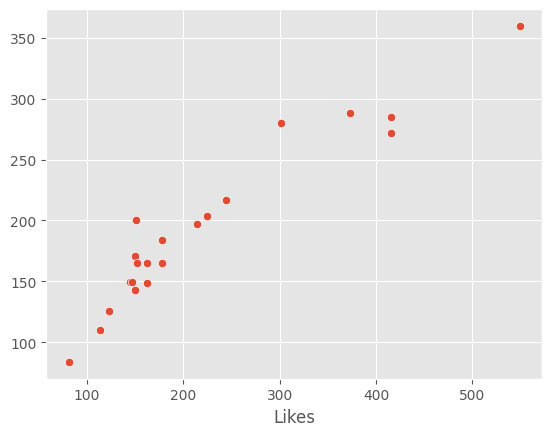

In [96]:
sns.scatterplot(x=y_test,y=y_pred)
plt.show()

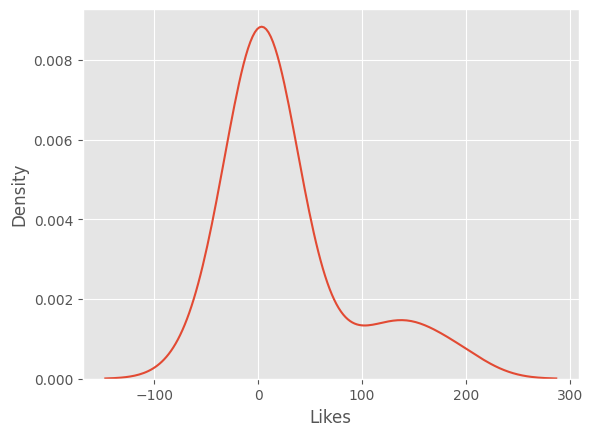

In [97]:
residuals = y_test-y_pred
sns.kdeplot(residuals)
plt.show()

#Feature Importances

In [98]:
x.columns

Index(['Impressions', 'From Home', 'From Hashtags', 'From Explore',
       'From Other', 'Saves', 'Comments', 'Shares', 'Profile Visits',
       'Follows', 'caption_len', 'hashtag_len', 'save_rate', 'share_rate',
       'Profile_Visit_Rate'],
      dtype='object')

In [99]:
model.feature_importances_

array([0.34134493, 0.04606385, 0.03603252, 0.02125296, 0.0360229 ,
       0.42563922, 0.00602449, 0.02118282, 0.01395774, 0.01374797,
       0.01960984, 0.0021101 , 0.00561702, 0.00485101, 0.00654263])

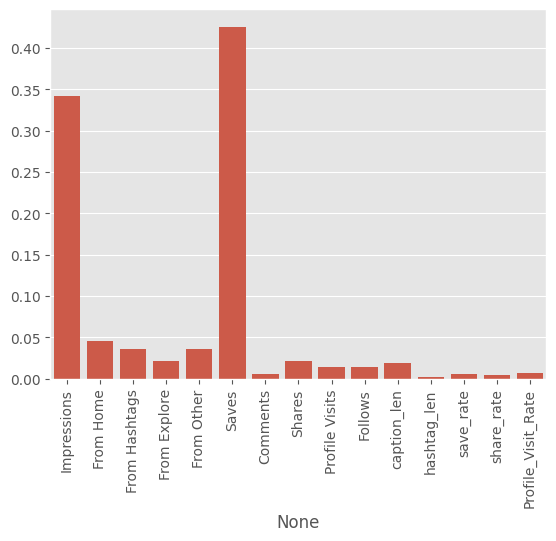

In [100]:
sns.barplot(x = x.columns,y = model.feature_importances_)
plt.xticks(rotation=90)
plt.show()

In [102]:
results = pd.DataFrame()
results['Features'] = x.columns
results['Importances'] = model.feature_importances_
results

,Features,Importances
0,Impressions,0.341345
1,From Home,0.046064
2,From Hashtags,0.036033
3,From Explore,0.021253
4,From Other,0.036023
5,Saves,0.425639
6,Comments,0.006024
7,Shares,0.021183
8,Profile Visits,0.013958
9,Follows,0.013748


In [103]:
results = pd.DataFrame()
results['Features'] = x.columns
results['Importances'] = model.feature_importances_

imp_cols = results.sort_values(by='Importances',ascending=False).head(7)['Features'].values.tolist()
imp_cols

['Saves',
 'Impressions',
 'From Home',
 'From Hashtags',
 'From Other',
 'From Explore',
 'Shares']

In [104]:
data = df[imp_cols+['Likes']]
data

,Saves,Impressions,From Home,From Hashtags,From Other,From Explore,Shares,Likes
0,-0.133753,-0.319495,0.529220,-0.294557,-0.408193,0.342933,-0.229660,162
1,0.737183,0.374807,0.678281,0.327131,-0.075061,0.786424,0.829918,224
2,-1.389649,-0.258289,-0.151690,-0.142926,1.493050,-3.919125,-1.390200,131
3,0.590599,0.013421,0.650868,-0.807132,-0.140060,0.626019,0.093657,213
4,-0.161565,-1.579242,-0.917335,-1.654799,-0.853541,-0.203421,-0.430278,123
...,...,...,...,...,...,...,...,...
114,1.932539,1.703115,2.026407,0.893750,-0.087659,1.853154,2.031878,373
115,0.286741,0.489970,-0.442454,0.006942,-0.255867,1.246165,-1.390200,148
116,-1.591351,-0.190012,-2.947218,0.132881,-0.982162,0.892466,-1.390200,92
117,2.550220,2.360719,2.943630,0.933281,0.631551,2.697622,2.934496,549


In [105]:
x = data.drop(['Likes'],axis=1)
y = data['Likes']

x_train,x_test,y_train,y_test = tts(x,y,test_size=0.2,random_state=42)

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

x_train.mean(axis=0)

array([ 4.66019541e-17, -2.87835599e-17, -3.28954970e-17, -4.66019541e-17,
        1.19931500e-17, -1.37064571e-17,  4.38606627e-17])

In [106]:
final_model = RandomForestRegressor()
final_model.fit(x_train,y_train)
y_pred = final_model.predict(x_test)
mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)
mape = mean_absolute_percentage_error(y_test,y_pred)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.4f}")

Mean Absolute Error (MAE): 36.8405
R² Score: 0.7073
Mean Absolute Percentage Error (MAPE): 0.1229


#Model Saving

In [107]:
with open('final_model.pkl','wb') as f:
  pickle.dump(final_model,f)

In [108]:
with open('/content/final_model.pkl','rb') as f:
  loaded_model = pickle.load(f)


loaded_model

RandomForestRegressor()

In [109]:
data.sample(1)

,Saves,Impressions,From Home,From Hashtags,From Other,From Explore,Shares,Likes
19,-1.427661,-1.730856,-2.031845,-0.754065,-0.795184,-0.210787,1.241447,72


In [114]:
test = [[-1.427661	,-1.730856,	-2.031845	,-0.754065	,-0.795184	,-0.210787	,1.241447	]]
test = scaler.transform(test)
float(loaded_model.predict(test)[0])

75.41

In [115]:
data.sample(1)

,Saves,Impressions,From Home,From Hashtags,From Other,From Explore,Shares,Likes
79,0.411968,0.425474,0.541394,0.612734,-0.28747,0.063,-0.057455,178


#Deployment

In [116]:
# Ask user for input features (excluding Likes)
saves = float(input("Enter Saves: "))
impressions = float(input("Enter Impressions: "))
from_home = float(input("Enter From Home: "))
from_hashtags = float(input("Enter From Hashtags: "))
from_other = float(input("Enter From Other: "))
from_explore = float(input("Enter From Explore: "))
shares = float(input("Enter Shares: "))

test = [[saves,impressions,from_home,from_hashtags,from_other,from_explore,shares]]

test = scaler.transform(test)
prediction = float(loaded_model.predict(test)[0])

print('The Prediction for Likes is approximately:',prediction)

Enter Saves: 0.411968
Enter Impressions: 0.425474
Enter From Home: 0.541394
Enter From Hashtags: 0.612734
Enter From Other: -0.28747
Enter From Explore: 0.063
Enter Shares: -0.057455
The Prediction for Likes is approximately: 187.54
